# Визуализация данных

In [1]:
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Задание 1.1. Загрузка данных
1. Пройди по [ссылке](TODO CHANGE ME) на хранилище с датасетом и словарем с расшифровкой вопросов .
2. Загрузи ответы респондентов, обработанные в предыдущем проекте, из файла 
`kaggle_survey_2025_responses.csv` в переменную `responses`.
3. Загрузи словарь с расшифровкой вопросов из файла `name2question.json` в переменную `name2question`.
4. Выведи размерность DataFrame `responses` и длину словаря `name2question`.
5. Убедись, что проверки с помощью `assert` проходят без ошибок и данные загружены корректно.

In [2]:
import pandas as pd

responses = pd.read_csv("..\datasets\kaggle_survey_2025_responses.csv")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\TEMP\ipykernel_9660\3362334320.py:3: SyntaxWarning: invalid escape sequence '\d'
  responses = pd.read_csv("..\datasets\kaggle_survey_2025_responses.csv")
C:\TEMP\ipykernel_9660\3362334320.py:3: DtypeWarning: Columns (2,21,47,55,63,84,97,108,111,122,124,149,150,154,155,156,157,160,167,171,177,179,182,193,197,201,207,209,210,211,216,217,218,219,222,238,243,245,247,248,261,275,289,303,305,312,321,328,339,340,346,353,365,366,367,369,370,376,379,382,383,389,390,391,392,393) have mixed types. Specify dtype option on import or set low_memory=False.
  responses = pd.read_csv("..\datasets\kaggle_survey_2025_responses.csv")


In [3]:
import json

with open("..\datasets\\name2question.json", "r", encoding="utf-8") as file:
  name2question = json.load(file)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\TEMP\ipykernel_9660\4260344958.py:3: SyntaxWarning: invalid escape sequence '\d'
  with open("..\datasets\\name2question.json", "r", encoding="utf-8") as file:


In [4]:
name2question

{'Q28_Part_12': {'question': 'Which of the following machine learning products have you used at work or school in the last 5 years? (Select all that apply) - Selected Choice - Google Cloud Video Intelligence API',
  'source': 'multiple'},
 'Q28_Part_3': {'question': 'Which of the following machine learning products have you used at work or school in the last 5 years? (Select all that apply) - Selected Choice - Amazon Rekognition',
  'source': 'multiple'},
 'Q30_Part_21': {'question': 'Which of the following big data and analytics products have you used at work or school in the last 5 years? (Select all that apply) - Selected Choice - IBM InfoSphere DataStorage',
  'source': 'multiple'},
 'Q38_Part_10': {'question': 'Who/what are your favorite media sources that report on data science topics? (Select all that apply) - Selected Choice - FiveThirtyEight.com',
  'source': 'multiple'},
 'Q35_Part_5': {'question': 'What percentage of your current machine learning/data science training falls 

In [5]:
print(responses.shape)
print(len(name2question))

(18696, 394)
394


In [6]:
assert responses.shape[0] == 18696

In [7]:
assert responses.shape[1] == len(name2question) == 394

### Задание 1.2. Круговая диаграмма
1. Используя библиотеку `matplotlib`, построй круговую диаграмму (*Pie Chart*), отображающую распределение респондентов по возрастным категориям.
2. С помощью параметра `explode` выдели сектор с наибольшей долей.
3. Объедини категории, доля которых составляет менее 5% от общего числа респондентов, в одну группу под названием `"Other"`.
4. Отсортируй категории по возрастанию возраста.
5. Добавь к диаграмме легенду и информативный заголовок.

<img src="../misc/images/task_2.png" alt="task_2" width="400" height="400">

In [8]:
age_percent = responses["Q2"].value_counts(normalize=True) * 100
print(age_percent)

Q2
25-29    25.534874
22-24    21.453787
30-34    15.891100
18-21    12.639067
35-39     9.467266
40-44     5.712452
45-49     3.717373
50-54     2.545999
55-59     1.428113
60-69     1.256953
70-79     0.208601
80+       0.144416
Name: proportion, dtype: float64


In [9]:
age_counts = responses["Q2"].value_counts()

In [10]:
percent = age_counts / age_counts.sum()

small = percent < 0.05

other = age_counts[small].sum()

age_counts = age_counts[~small]

if other > 0:
  age_counts.loc["Other"] = other

In [11]:
order = [
    "18-21",
    "22-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "Other"
]

age_counts = age_counts.reindex(order).dropna()

In [12]:
print(age_counts)

Q2
18-21    2363
22-24    4011
25-29    4774
30-34    2971
35-39    1770
40-44    1068
Other    1739
Name: count, dtype: int64


In [13]:
explode = [0.08 if i == age_counts.idxmax() else 0
           for i in age_counts.index]

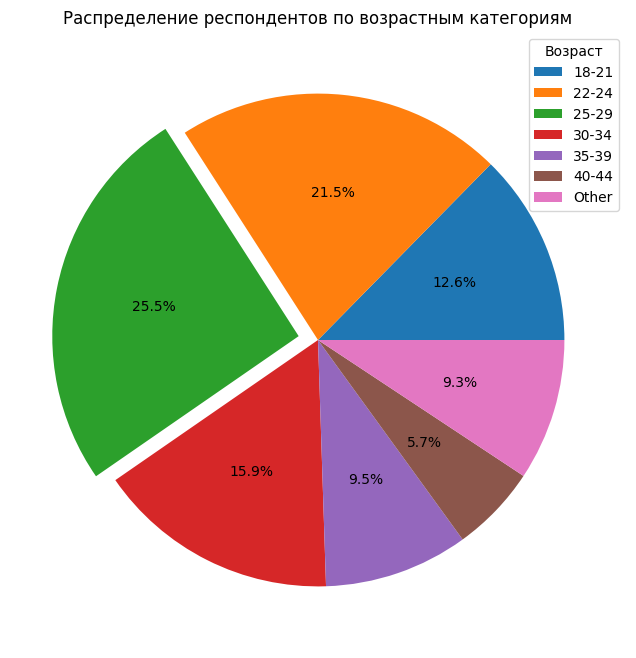

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=None,
    explode=explode,
    autopct="%1.1f%%",
)

plt.title("Распределение респондентов по возрастным категориям")
plt.legend(age_counts.index, title="Возраст")

plt.show()

### Задание 1.3. Столбцовая диаграмма
1. С помощью библиотеки `seaborn` построй столбцовую диаграмму (*Bar Plot*), отражающую популярность библиотек для визуализации данных.
2. Отфильтруй данные, оставив только ответы, относящиеся к библиотекам для визуализации данных.
3. Исключи из анализа категории с частотой встречаемости менее **500 наблюдений**.
4. Отсортируй библиотеки по убыванию популярности.
5. Используй горизонтальную ориентацию столбцов.
6. Применяй цветовую палитру `'colorblind'`.
7. Добавь информативный заголовок и поверни подписи на оси X на 30 градусов.

<img src="../misc/images/task_3.png" alt="task_3" width="600" height="400">

In [15]:
for name, info in name2question.items():
  if "libraries" in info["question"]:
    print(name, info["question"])

Q21_Part_11 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Lattice
Q21_Part_2 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Matplotlib
Q21_Part_12 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - None
Q21_Part_9 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Geoplotlib
Q21_Part_8 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Seaborn
Q21_Part_3 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Altair
Q21_Part_7 What data visualization libraries or tools have you used in the past 5 years? (Select all that apply) - Selected Choice - Bokeh
Q21_Part_10

In [16]:
viz_columns = [col for col in responses.columns if col.startswith("Q21")]
viz_columns

['Q21_Part_1',
 'Q21_Part_2',
 'Q21_Part_3',
 'Q21_Part_4',
 'Q21_Part_5',
 'Q21_Part_6',
 'Q21_Part_7',
 'Q21_Part_8',
 'Q21_Part_9',
 'Q21_Part_10',
 'Q21_Part_11',
 'Q21_Part_12',
 'Q21_Part_13',
 'Q21_OTHER_TEXT']

In [17]:
library_count = {}

for col in viz_columns:
  for value in responses[col].dropna():
    library_count[value] = library_count.get(value, 0) + 1

library_count = pd.Series(library_count)

library_count = library_count[library_count >= 500]
library_count = library_count.sort_values(ascending=False)

C:\TEMP\ipykernel_9660\1399040471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


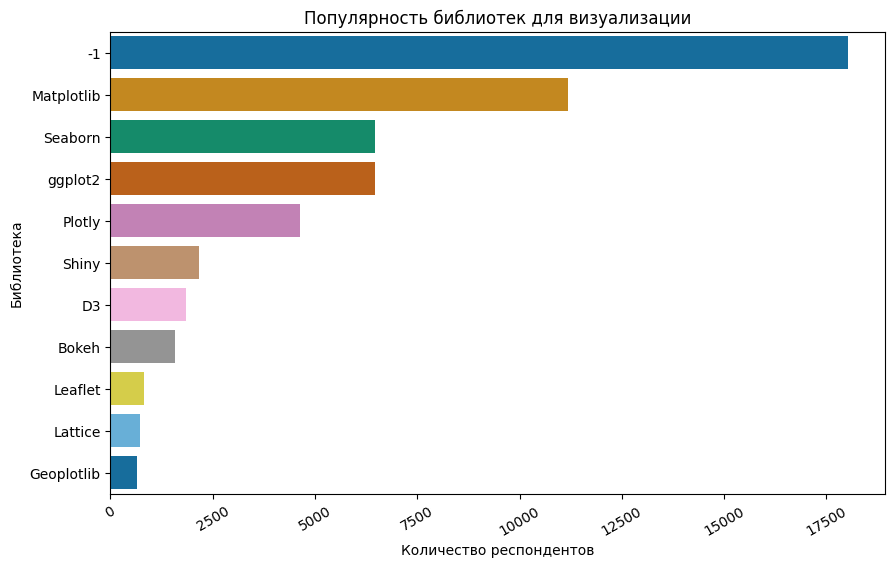

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
  x=library_count.values,
  y=library_count.index,
  palette="colorblind"
)

plt.title("Популярность библиотек для визуализации")
plt.xlabel("Количество респондентов")
plt.ylabel("Библиотека")

plt.xticks(rotation=30)

plt.show()

### Задание 1.4. Диаграмма «ящик с усами»
1. С помощью библиотеки `seaborn` построй диаграмму **«ящик с усами» (box plot)**, отображающую распределение заработка по различным специальностям.
2. Исключи из анализа категории **студентов** и **неработающих**.
3. Зарплаты представлены категориями ("0-10000", "10-20000", "20-30000", ..., "500000+"). Преобразуй их в числовые значения через **соответствие категорий средним значениям диапазонов**: "0-10000" → 5000, "10-20000" → 15000, "20-30000" → 25000, "500000+" → 500000. Респондентов с неизвестным заработком исключи из анализа.
4. Отобрази по оси **Y** должности, а по оси **X** заработок в год.
5. Отсортируй специальности **по убыванию медианного значения заработка**.
6. Ограничь диапазон оси **X** значением **до 500 000 $** в год.
7. Установи **шаг сетки по оси X** равным **50 000**.
8. Используй цветовую палитру `colorblind`.
9. Добавь **заголовок** и **подписи осей**.

<img src="../misc/images/task_4.png" alt="task_4" width="800" height="400">

In [19]:
responses["Q9"]

0                NaN
1          10-20,000
2           0-10,000
3                NaN
4           0-10,000
            ...     
18691      10-20,000
18692    250-300,000
18693            NaN
18694      10-20,000
18695            NaN
Name: Q9, Length: 18696, dtype: object

In [20]:
sorted(responses["Q9"].dropna().unique())

['0-10,000',
 '10-20,000',
 '100-125,000',
 '125-150,000',
 '150-200,000',
 '20-30,000',
 '200-250,000',
 '250-300,000',
 '30-40,000',
 '300-400,000',
 '40-50,000',
 '400-500,000',
 '50-60,000',
 '500,000+',
 '60-70,000',
 '70-80,000',
 '80-90,000',
 '90-100,000',
 'I do not wish to disclose my approximate yearly compensation']

In [21]:
def interval_to_mean(interval):
    if pd.isna(interval):
        return None

    if interval == "I do not wish to disclose my approximate yearly compensation":
        return None

    if interval == "500,000+":
        return 500000

    interval = interval.replace(",", "")

    left, right = interval.split("-")

    left = int(left)
    right = int(right)

    return (left + right) // 2

In [22]:
roles = responses.copy()

roles["Salary"] = roles["Q9"].apply(interval_to_mean)
roles = roles.dropna(subset="Salary")

In [23]:
print(roles["Q6"].value_counts())

Q6
Data Scientist             2596
Student                    2151
Software Engineer          1932
Data Analyst               1172
Other                       845
Research Scientist          771
Business Analyst            480
Consultant                  478
Data Engineer               436
Manager                     375
Research Assistant          368
Product/Project Manager     264
Chief Officer               204
Statistician                148
DBA/Database Engineer        98
Principal Investigator       74
Marketing Analyst            71
Developer Advocate           65
Salesperson                  63
Data Journalist               7
Name: count, dtype: int64


In [24]:
print(roles["Q6_OTHER_TEXT"].value_counts())

Q6_OTHER_TEXT
-1                           11753
-2                             698
Professor                       34
Teacher                         29
Machine Learning Engineer       28
Lecturer                        15
Engineer                        14
Actuary                         10
Instructor                       9
Machine learning engineer        5
Assistant Professor              3
Name: count, dtype: int64


In [25]:
roles = roles[~roles["Q6"].isin(["Student", "Currently not employed"])]

In [26]:
order = (
  roles
  .groupby("Q6")["Salary"]
  .median()
  .sort_values(ascending=False)
  .index
)

C:\TEMP\ipykernel_9660\951301088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0, 0.5, 'Должность')

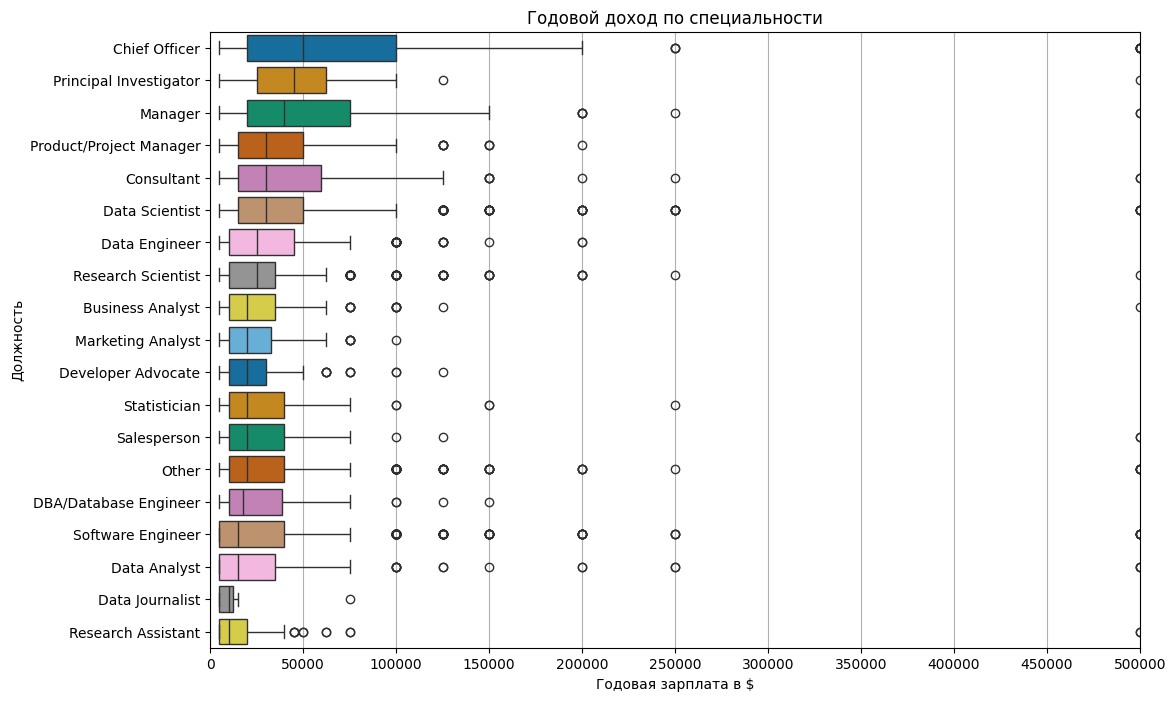

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.boxplot(
  data=roles,
  x="Salary",
  y="Q6",
  order=order,
  palette="colorblind"
)

plt.xlim(0, 500000)
plt.xticks(range(0, 500001, 50000))
plt.grid(axis="x")
plt.title("Годовой доход по специальности")
plt.xlabel("Годовая зарплата в $")
plt.ylabel("Должность")

### Задание 1.5. Географическая карта респондентов
1. С помощью библиотеки `plotly` построй **интерактивную карту мира**, отображающую количество респондентов из каждой страны.
2. Для визуализации используй тип **choropleth map** (тепловая карта по регионам).
3. Закрась страны в зависимости от числа респондентов: чем больше значение, тем насыщеннее цвет.
4. Применяй цветовую шкалу `Viridis` для повышения читаемости.
5. Добавь **заголовок**, **легенду** и **подпись шкалы**, поясняющую интенсивность окрашивания.
6. Сделай карту интерактивной: при наведении курсора должны отображаться **названия стран** и **количество респондентов**.

<img src="../misc/images/task_5.png" alt="task_5" width="800" height="400">

In [28]:
countries = (
    responses
    .groupby("Q3")
    .size()
    .reset_index(name="Count")
)
countries

,Q3,Count
0,Argentina,97
1,Australia,259
2,Austria,49
3,Bangladesh,84
4,Belarus,67
5,Belgium,88
6,Brazil,566
7,Canada,490
8,Chile,61
9,China,1255


In [29]:
fig = px.choropleth(
    countries,
    locations="Q3",
    locationmode="country names",
    color="Count",
    color_continuous_scale="Viridis",
    labels={"Count": "Количество респондентов"}
)

fig.update_layout(
    title="Распределение респондентов по странам"
)

fig.write_html("countries_map.html")

C:\TEMP\ipykernel_9660\1666526446.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


<img src="../misc/images/map.png">

### Задание 1.6. Диаграмма Sankey
1. Построй диаграмму Sankey, показывающую связь между уровнем образования и должностью респондентов.
2. Для основных степеней образования отобрази логическую иерархию:
   - Для респондентов с **Doctoral degree** покажи путь: `Bachelor's degree` → `Master's degree` → `Doctoral degree` → должность
   - Для респондентов с **Master's degree** покажи путь: `Bachelor's degree` → `Master's degree` → должность
   - Для респондентов с **Bachelor's degree** покажи связь: `Bachelor's degree` → должность
   - Для остальных уровней образования покажи прямую связь: уровень образования → должность
3. Примени разные контрастные цвета для разных типов узлов (степени бакалавра, магистра, доктора, остальные уровни образования, должности).
4. Толщина потоков должна отражать частоту переходов между узлами.

<img src="../misc/images/task_6.png" alt="task_6" width="800" height="600">


In [30]:
education = responses["Q4"]
role = responses["Q6"]
data = responses[["Q4", "Q6"]].copy()

In [31]:
links = []
for _, row in data.iterrows():
  education = row["Q4"]
  role = row["Q6"]

  if education == "Doctoral degree":
    links.append(("Bachelor's degree", "Master's degree"))
    links.append(("Master's degree", "Doctoral degree"))
    links.append(("Doctoral degree", role))
  elif education == "Master's degree":
    links.append(("Bachelor's degree", "Master's degree"))
    links.append(("Master's degree", role))
  elif education == "Bachelor's degree":
    links.append(("Bachelor's degree", role))
  else:
    links.append((education, role))

print(links[:15])

[("Bachelor's degree", "Master's degree"), ("Master's degree", 'Doctoral degree'), ('Doctoral degree', 'Consultant'), ('Bachelor’s degree', 'Other'), ('Master’s degree', 'Data Scientist'), ('Master’s degree', 'Not employed'), ('Master’s degree', 'Data Analyst'), ('Bachelor’s degree', 'Data Scientist'), ("Bachelor's degree", "Master's degree"), ("Master's degree", 'Doctoral degree'), ('Doctoral degree', 'Other'), ('Master’s degree', 'Other'), ('Master’s degree', 'Not employed'), ('Master’s degree', 'Software Engineer'), ('Bachelor’s degree', 'Student')]


In [32]:
links_df = pd.DataFrame(
  links,
  columns=["source", "target"]
)

links_df.head()

,source,target
0,Bachelor's degree,Master's degree
1,Master's degree,Doctoral degree
2,Doctoral degree,Consultant
3,Bachelor’s degree,Other
4,Master’s degree,Data Scientist


In [33]:
links_df = (
    links_df
    .groupby(["source", "target"])
    .size()
    .reset_index(name="value")
)
links_df

,source,target,value
0,Bachelor's degree,Master's degree,2694
1,Bachelor’s degree,Business Analyst,200
2,Bachelor’s degree,Chief Officer,55
3,Bachelor’s degree,Consultant,175
4,Bachelor’s degree,DBA/Database Engineer,48
...,...,...,...
139,Some college/university study without earning ...,Research Scientist,6
140,Some college/university study without earning ...,Salesperson,8
141,Some college/university study without earning ...,Software Engineer,118
142,Some college/university study without earning ...,Statistician,4


In [34]:
nodes = pd.concat([
  links_df["source"],
  links_df["target"]
]).unique()
nodes

array(["Bachelor's degree", 'Bachelor’s degree', 'Doctoral degree',
       'I prefer not to answer', "Master's degree", 'Master’s degree',
       'No formal education past high school', 'Professional degree',
       'Some college/university study without earning a bachelor’s degree',
       'Business Analyst', 'Chief Officer', 'Consultant',
       'DBA/Database Engineer', 'Data Analyst', 'Data Engineer',
       'Data Journalist', 'Data Scientist', 'Developer Advocate',
       'Manager', 'Marketing Analyst', 'Not employed', 'Other',
       'Principal Investigator', 'Product/Project Manager',
       'Research Assistant', 'Research Scientist', 'Salesperson',
       'Software Engineer', 'Statistician', 'Student'], dtype=object)

In [35]:
node_dict = {
  node: i
  for i, node in enumerate(nodes)
}
node_dict

{"Bachelor's degree": 0,
 'Bachelor’s degree': 1,
 'Doctoral degree': 2,
 'I prefer not to answer': 3,
 "Master's degree": 4,
 'Master’s degree': 5,
 'No formal education past high school': 6,
 'Professional degree': 7,
 'Some college/university study without earning a bachelor’s degree': 8,
 'Business Analyst': 9,
 'Chief Officer': 10,
 'Consultant': 11,
 'DBA/Database Engineer': 12,
 'Data Analyst': 13,
 'Data Engineer': 14,
 'Data Journalist': 15,
 'Data Scientist': 16,
 'Developer Advocate': 17,
 'Manager': 18,
 'Marketing Analyst': 19,
 'Not employed': 20,
 'Other': 21,
 'Principal Investigator': 22,
 'Product/Project Manager': 23,
 'Research Assistant': 24,
 'Research Scientist': 25,
 'Salesperson': 26,
 'Software Engineer': 27,
 'Statistician': 28,
 'Student': 29}

In [36]:
source = links_df["source"].map(node_dict)

target = links_df["target"].map(node_dict)

value = links_df["value"]

In [37]:
node_colors = []

for node in nodes:
    if node == "Bachelor's degree":
        node_colors.append("royalblue")
    elif node == "Master's degree":
        node_colors.append("orange")
    elif node == "Doctoral degree":
        node_colors.append("crimson")
    elif "degree" in node:
        node_colors.append("green")
    else:
        node_colors.append("gray")

In [38]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=nodes,
            color=node_colors,
            pad=20,
            thickness=20
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Связь между уровнем образования и должностью",
    font_size=12
)

fig.write_html("sankey.html")

<img src="../misc/images/sankey.png">